DBSCAN ALGORİTMASI: TEORİ, AVANTAJLAR VE KULLANIM NOTLARI


1. TEMEL TEORİ VE ÇALIŞMA MANTIĞI:
- Yoğunluk Tabanlı Kümeleme (Density-Based Clustering) algoritmasıdır.
- Veri noktalarının birbirine olan yakınlık ve yoğunluğuna göre kümeler oluşturur.
- 2 Temel Hiperparametresi Vardır:
  * eps (Epsilon): Bir noktanın komşuluk yarıçapı mesafe sınırı.
  * min_samples: Bir bölgenin küme oluşturabilmesi için eps yarıçapı içinde 
    bulunması gereken minimum nokta sayısı.
- Noktaları 3 Türde Sınıflandırır:
  1. Çekirdek Nokta (Core Point): Yarıçapı içinde en az min_samples kadar nokta bulunan nokta.
  2. Sınır Nokta (Border Point): Çekirdek nokta komşuluğunda olan ama kendisi çekirdek olmayan nokta.
  3. Gürültü / Aykırı Değer (Noise / Outlier): Hiçbir komşuluğa girmeyen nokta (Label = -1).

2. AVANTAJLAR:
- Küme sayısını (K) önceden belirtmeye GEREK YOKTUR. Algoritma küme sayısını kendisi bulur.
- Karmaşık ve düzensiz geometrik şekillerdeki kümeleri (halka, hilal vb.) başarıyla tespit eder.
- Aykırı değerleri (Gürültü / Noise) tespit etmede ve veri temizlemede çok başarılıdır (Label -1 verir).

3. DEZAVANTAJLAR VE DİKKAT EDİLMESİ GEREKENLER:
- Farklı yoğunluklara sahip verilerde eps ve min_samples ayarı yapmak zordur.
- Yüksek boyutlu verilerde (Mesafe Laneti / Curse of Dimensionality) performansı düşebilir.
- Verilerin uzaklık tabanlı ölçülebilmesi için ölçeklendirilmesi (StandardScaler / MinMaxScaler) şarttır.

HDBSCAN ALGORİTMASI: TEORİ, AVANTAJLAR VE KULLANIM NOTLARI

1. TEMEL TEORİ VE ÇALIŞMA MANTIĞI:
- DBSCAN ile Hiyerarşik Kümelemenin (Hierarchical Clustering) birleşimidir.
- Yoğunluk tabanlı bir algoritmadır ancak DBSCAN'in en büyük zayıflığı olan 
  "tek bir sabit eps (epsilon) mesafesi kullanma" zorunluluğunu ortadan kaldırır.
- Farklı yoğunluklara ve ölçeklere sahip veri gruplarını hiyerarşik bir ağaç 
  (dendrogram) yapısı kurarak otomatik olarak tespit eder.
- Sabit bir eps parametresi gerektirmez. En önemli parametresi 'min_cluster_size'dır.

2. DBSCAN VE K-MEANS'E GÖRE AVANTAJLARI:
- Farklı Yoğunluktaki Kümeler: Veride hem çok sıkı hem de çok yayvan kümeler 
  varsa DBSCAN zorlanırken HDBSCAN hepsini başarıyla ayırır.
- Parameter-Light (Daha Az Parametre): 'eps' arama derdi yoktur, sadece minimum 
  küme büyüklüğünü (min_cluster_size) belirlemek yeterlidir.
- Kararlı Aykırı Değer Tespiti: Gürültü ve aykırı değerleri (Label = -1) tespit 
  etmede çok güçlüdür ve her noktanın kümeye aidiyet olasılığını (soft clustering) sunar.

3. KULLANIM ALANLARI VE DEZAVANTAJLARI:
- Karmaşık, düzensiz ve farklı yoğunluktaki gerçek dünya verilerinde en başarılı 
  kümeleme algoritmalarından biridir.
- Çok büyük veri setlerinde standart K-Means'e göre bellek ve hesaplama maliyeti 
  daha yüksek olabilir.

In [1]:
##################

DBSCAN vs HDBSCAN (KISA ÖZET)

1. EPSILON (MESAFA) PARAMETRESİ:
- DBSCAN: Sabit bir eps (yarıçap) ister; doğru eps'yi bulmak zordur.
- HDBSCAN: Epsilon GEREKTİRMEZ; mesafeyi veriye göre otomatik ayarlar.

2. YOĞUNLUK UYUMU:
- DBSCAN: Tüm veride TEK bir yoğunluk arar; seyrek/sıkı kümeleri karıştırır.
- HDBSCAN: FARKLI yoğunluktaki kümeleri hiyerarşik yapısıyla sorunsuz ayırır.

3. HİPERPARAMETRE KOLAYLIĞI:
- DBSCAN: Hem 'eps' hem 'min_samples' ayarı gerektirir.
- HDBSCAN: Sadece 'min_cluster_size' (min. küme boyutu) vermek yeterlidir.

ÖZET: HDBSCAN, DBSCAN'in eps seçme zorluğunu ve farklı yoğunluklardaki başarısızlığını çözen gelişmiş halidir.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('28-urban_pedestrian_locations_with_labels.csv')

In [3]:
df.head()

,x_position,y_position,true_cluster
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,0
4,0.293226,1.057185,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   x_position    500 non-null    float64
 1   y_position    500 non-null    float64
 2   true_cluster  500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


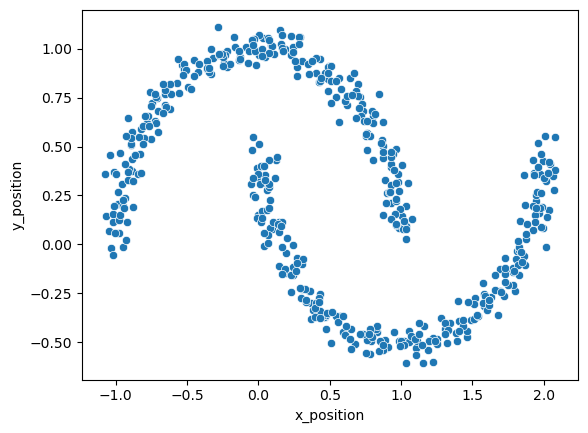

In [5]:
sns.scatterplot(data=df,x='x_position',y='y_position')
plt.show()

In [8]:
df = df.drop('true_cluster',axis = 1)

In [9]:
df.head()

,x_position,y_position
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()

In [12]:
X_scaler = scaler.fit_transform(df)

In [13]:
from sklearn.cluster import DBSCAN

In [14]:
dbscan = DBSCAN()

In [16]:
dbscan.fit(X_scaler)

DBSCAN()

In [17]:
dbscan.labels_

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

In [19]:
X_scaler = pd.DataFrame(X_scaler,columns=['x_position','y_position'])

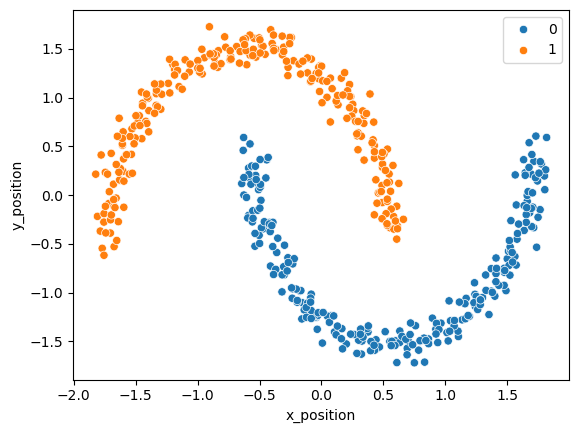

In [22]:
sns.scatterplot(data=X_scaler,x='x_position',y='y_position',hue=dbscan.labels_)
plt.show()

model yoğunluk zincirini takip ederek birbirine teğet gibi duran ama ayrı olan iki iç içe yapıyı tam olarak doğru kümelemiş

HYPERPARAMETER TUNING 

suan burada hyperparameter tuning yapmaya gerek yok ama baska bir datada yapmak gerekirse diye gostermelik yapiruz 

In [25]:
eps_values = [0.1,0.2,0.3,0.4,0.5,0.6]
min_samples_values = [4,5,6]

In [27]:
from sklearn.metrics import silhouette_score

In [33]:
results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaler)
        labels = db.labels_

        if len(set(labels)) <= 1:
            continue

        silhouette = silhouette_score(X_scaler, labels)
        results.append(
            {
                "eps": eps,
                "min_samples": min_samples,
                "Silhoutte": silhouette,
                "n_clusters": len(set(labels)) - (1 if -1 in labels else 0)
            }
        )

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Silhoutte", ascending=False)

Bu kod, farklı eps ve min_samples değerlerini tek tek deneyerek DBSCAN algoritmasının kümeleme performansını Silhouette Skoru ile ölçer. Elde edilen sonuçları bir tabloya aktarıp skora göre büyükten küçüğe sıralayarak en ideal hiperparametre kombinasyonunu tespit etmeyi sağlar

In [34]:
results_df

,eps,min_samples,Silhoutte,n_clusters
4,0.2,5,0.389338,2
3,0.2,4,0.389338,2
14,0.5,6,0.389338,2
11,0.4,6,0.389338,2
5,0.2,6,0.389338,2
6,0.3,4,0.389338,2
8,0.3,6,0.389338,2
7,0.3,5,0.389338,2
9,0.4,4,0.389338,2
10,0.4,5,0.389338,2


HDBScan

In [35]:
from sklearn.cluster import HDBSCAN

In [36]:
hdbscan = HDBSCAN()

In [38]:
hdbscan.fit(X_scaler)

HDBSCAN()

In [39]:
hdbscan.labels_

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

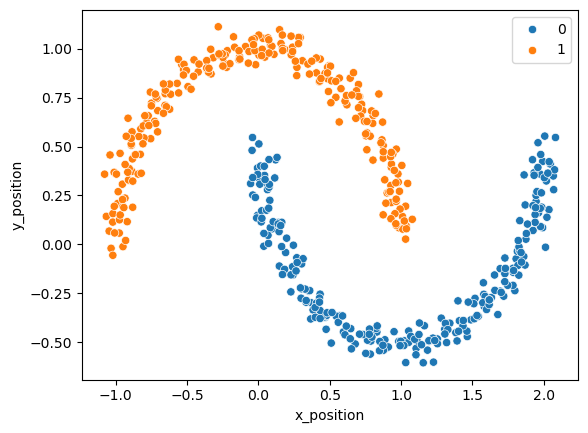

In [40]:
sns.scatterplot(data=df,x='x_position',y='y_position',hue=hdbscan.labels_)
plt.show()

In [43]:
min_cluster_size = [3, 5, 6, 10]
min_samples_values = [None, 3, 5, 7]  # İsmi 'min_samples_values' yaptık

In [44]:
results = []

for min_cluster in min_cluster_size:
    for min_samples in min_samples_values:  # Liste ismiyle eşleşti
        hdb = HDBSCAN(min_cluster_size=min_cluster, min_samples=min_samples).fit(X_scaler)
        labels = hdb.labels_

        if len(set(labels)) <= 1:
            continue

        silhouette = silhouette_score(X_scaler, labels)
        results.append(
            {
                "min_cluster_size": min_cluster,
                "min_samples": min_samples,
                "Silhoutte": silhouette,
                "n_clusters": len(set(labels)) - (1 if -1 in labels else 0)
            }
        )

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Silhoutte", ascending=False)

In [45]:
results_df

,min_cluster_size,min_samples,Silhoutte,n_clusters
3,3,7.0,0.389338,2
2,3,5.0,0.389338,2
5,5,3.0,0.389338,2
4,5,NaN,0.389338,2
6,5,5.0,0.389338,2
7,5,7.0,0.389338,2
9,6,3.0,0.389338,2
8,6,NaN,0.389338,2
12,10,NaN,0.389338,2
13,10,3.0,0.389338,2
